# KOSPI 200 투자전략 비교
2016.09.01 ~ 2026.08.31의 10년간 다섯 전략을 동일 조건에서 비교하였다.
B&H, Connors RSI(2), RSI + Bollinger, Momentum Top20, Momentum + Price를 대상으로 하였다.

## 0. 실행과 고정 설정
Colab에 **이 노트북 하나를 업로드하고 전체 실행**한다. 기본 경로는 `Path.cwd()`이므로 Drive를 연결할 필요가 없음.
성공적으로 수집한 가격은 캐시를 재사용한다. 기존 작업 폴더에서 실행하면 같은 캐시를 사용할 수 있다.

In [ ]:
import sys, subprocess
if sys.version_info < (3,11):
    raise RuntimeError('Python 3.11+ required. Use a current Colab runtime.')
subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q',
    'numpy>=1.24,<3', 'pandas>=2.1,<4', 'matplotlib>=3.7,<4', 'yfinance>=0.2.54,<2',
    'jinja2>=3.1,<4', 'pykrx>=1.2.8,<2'])

0

In [ ]:
from pathlib import Path
import sys, importlib
RUNTIME = Path.cwd() / 'kospi200_runtime_v2'
RUNTIME.mkdir(exist_ok=True)
(RUNTIME / 'quant_utils.py').write_text('"""Price strategy research utilities. See README.md for execution assumptions."""\nimport numpy as np\nimport pandas as pd\n\n# ---------------- indicators ----------------\n\ndef rsi(px: pd.Series, n: int = 14) -> pd.Series:\n    d = px.diff()\n    up = d.clip(lower=0.0)\n    dn = (-d).clip(lower=0.0)\n    # Wilder smoothing == EWM with alpha = 1/n\n    ru = up.ewm(alpha=1.0 / n, adjust=False, min_periods=n).mean()\n    rd = dn.ewm(alpha=1.0 / n, adjust=False, min_periods=n).mean()\n    rs = ru / rd.replace(0.0, np.nan)\n    out = 100.0 - 100.0 / (1.0 + rs)\n    return out.where(rd != 0.0, 100.0).mask((ru == 0) & (rd == 0), 50.0).rename("rsi")\n\n\ndef bollinger(px: pd.Series, n: int = 20, k: float = 2.0):\n    mid = px.rolling(n, min_periods=n).mean()\n    sd = px.rolling(n, min_periods=n).std(ddof=0)\n    return mid, mid - k * sd, mid + k * sd\n\n\ndef efficiency_ratio(px: pd.Series, n: int = 20) -> pd.Series:\n    """|net move| / sum(|daily move|) over n days. 1 = pure trend, 0 = pure chop."""\n    net = (px - px.shift(n)).abs()\n    path = px.diff().abs().rolling(n, min_periods=n).sum()\n    return (net / path.replace(0.0, np.nan)).rename("er")\n\n\ndef rolling_pct_rank(s: pd.Series, window: int = 252, min_periods: int = 126) -> pd.Series:\n    """Expanding-in-window percentile of the CURRENT value vs the trailing window.\n    Uses only data up to and including t -> no look-ahead."""\n    return s.rolling(window, min_periods=min_periods).rank(pct=True)\n\n\n# ---------------- signals (all long/flat, computed at close t) ----------------\n\ndef rsi2_wilder(px: pd.Series) -> pd.Series:\n    """Two-period Wilder RSI: seed with two changes, then alpha=1/2.\n    Missing values restart the seed; flat prices give 50, gains-only give 100.\n    """\n    values = pd.Series(px, dtype=float)\n    changes = values.diff().to_numpy()\n    result = np.full(len(values), np.nan)\n    gains, losses = [], []\n    avg_gain = avg_loss = None\n    for i, change in enumerate(changes):\n        if not np.isfinite(change):\n            gains, losses = [], []\n            avg_gain = avg_loss = None\n            continue\n        gain, loss = max(change, 0.0), max(-change, 0.0)\n        if avg_gain is None:\n            gains.append(gain)\n            losses.append(loss)\n            if len(gains) < 2:\n                continue\n            avg_gain, avg_loss = float(np.mean(gains)), float(np.mean(losses))\n        else:\n            avg_gain = (avg_gain + gain) / 2.0\n            avg_loss = (avg_loss + loss) / 2.0\n        result[i] = (50.0 if avg_gain == avg_loss == 0 else\n                     100.0 if avg_loss == 0 else\n                     100.0 - 100.0 / (1.0 + avg_gain / avg_loss))\n    return pd.Series(result, index=values.index, name=\'rsi2_wilder\')\n\n\ndef sig_connors_rsi2(px: pd.Series) -> pd.Series:\n    """Long/cash benchmark; close-t target, shifted by backtest exactly once.\n    Enter: close > SMA200 and Wilder RSI(2) < 5.\n    Exit: close > SMA5. SMA200 is an entry filter, not a stop.\n    No shorting, pyramiding, fixed stop, or maximum holding period.\n    """\n    r = rsi2_wilder(px)\n    sma200 = px.rolling(200, min_periods=200).mean()\n    sma5 = px.rolling(5, min_periods=5).mean()\n    valid = px.notna() & r.notna() & sma200.notna() & sma5.notna()\n    entry = (px > sma200) & (r < 5.0)\n    exit_ = px > sma5\n    position = np.full(len(px), np.nan)\n    holding = False\n    for i in range(len(px)):\n        if not valid.iloc[i]:\n            continue\n        if holding:\n            if exit_.iloc[i]:\n                holding = False\n        elif entry.iloc[i]:\n            holding = True\n        position[i] = float(holding)\n    return pd.Series(position, index=px.index, name=\'connors_rsi2\')\n\n\ndef sig_buyhold(px: pd.Series) -> pd.Series:\n    return pd.Series(1.0, index=px.index, name="buyhold")\n\n\n\n\ndef sig_momentum(px: pd.Series, lookback: int = 252, skip: int = 21) -> pd.Series:\n    """12-1 time-series momentum: return from t-lookback to t-skip."""\n    mom = px.shift(skip) / px.shift(lookback) - 1.0\n    return (mom > 0).astype(float).where(mom.notna()).rename("momentum")\n\n\ndef sig_rsi_bollinger(px: pd.Series, rsi_n=14, rsi_buy=30.0, bb_n=20, bb_k=2.0,\n                     exit_rsi=50.0) -> pd.Series:\n    """Entry: RSI < rsi_buy AND close <= lower band. Exit: RSI > exit_rsi OR close >= mid band.\n    Stateful loop because entry/exit are asymmetric."""\n    r = rsi(px, rsi_n)\n    mid, lo, _ = bollinger(px, bb_n, bb_k)\n    entry = (r < rsi_buy) & (px <= lo)\n    exit_ = (r > exit_rsi) | (px >= mid)\n    pos = np.zeros(len(px))\n    holding = False\n    e_arr, x_arr = entry.to_numpy(), exit_.to_numpy()\n    valid = r.notna().to_numpy() & mid.notna().to_numpy()\n    for i in range(len(px)):\n        if not valid[i]:\n            pos[i] = np.nan\n            continue\n        if holding:\n            if x_arr[i]:\n                holding = False\n        else:\n            if e_arr[i]:\n                holding = True\n        pos[i] = 1.0 if holding else 0.0\n    return pd.Series(pos, index=px.index, name="rsi_bollinger")\n\n\n# ---------------- regimes ----------------\n\ndef regime_frame(px: pd.Series, er_n=20, win=252, vol_n=60) -> pd.DataFrame:\n    er = efficiency_ratio(px, er_n)\n    er_r = rolling_pct_rank(er, win)\n    trend_up = (px > px.rolling(200, min_periods=200).mean())\n    vol = px.pct_change().rolling(vol_n, min_periods=vol_n).std() * np.sqrt(252)\n    vol_r = rolling_pct_rank(vol, win)\n\n    er_lab = pd.Series(pd.NA, index=px.index, dtype="object")\n    er_lab[er_r <= 1 / 3] = "chop"\n    er_lab[(er_r > 1 / 3) & (er_r <= 2 / 3)] = "mixed"\n    er_lab[er_r > 2 / 3] = "trend"\n\n    dir_lab = pd.Series(pd.NA, index=px.index, dtype="object")\n    dir_lab[trend_up] = "bull"\n    dir_lab[~trend_up & px.rolling(200, min_periods=200).mean().notna()] = "bear"\n\n    vol_lab = pd.Series(pd.NA, index=px.index, dtype="object")\n    vol_lab[vol_r <= 1 / 3] = "lowvol"\n    vol_lab[(vol_r > 1 / 3) & (vol_r <= 2 / 3)] = "midvol"\n    vol_lab[vol_r > 2 / 3] = "highvol"\n\n    return pd.DataFrame({"er": er, "er_rank": er_r, "regime_er": er_lab,\n                         "regime_dir": dir_lab, "vol": vol, "regime_vol": vol_lab})\n\n\n# ---------------- data and reproducibility ----------------\nfrom pathlib import Path\nimport hashlib\nimport json\n\n\ndef validate_prices(frame):\n    """Adjusted Open/Close must be from the same source and adjustment convention."""\n    d = frame.copy()\n    d.index = pd.DatetimeIndex(pd.to_datetime(d.index))\n    if d.index.tz is not None:\n        d.index = d.index.tz_localize(None)\n    d.index = d.index.normalize()\n    d = d.sort_index()\n    if d.index.has_duplicates or len(d) < 2:\n        raise ValueError(\'Prices require unique session dates and at least two rows.\')\n    for col in [\'Open\', \'Close\']:\n        if col not in d:\n            raise ValueError(f\'Missing price column: {col}\')\n        d[col] = pd.to_numeric(d[col], errors=\'raise\')\n        if not np.isfinite(d[col]).all() or (d[col] <= 0).any():\n            raise ValueError(f\'{col}: missing/nonpositive price; do not forward fill OHLC.\')\n    return d\n\n\ndef load_prices(ticker, start, end, cache_dir=\'cache\', local_csv=None, refresh=False):\n    """end is exclusive. A CSV override must contain Date, Open, Close (adjusted).\n\n    No synthetic fallback. A cache is specific to the ticker and exact date range.\n    """\n    cache = Path(cache_dir); cache.mkdir(parents=True, exist_ok=True)\n    key = f\'{ticker}_{pd.Timestamp(start):%Y%m%d}_{pd.Timestamp(end):%Y%m%d}_adj_v2\'\n    path = Path(local_csv) if local_csv else cache / f\'{key}.csv\'\n    if local_csv or (path.exists() and not refresh):\n        d = pd.read_csv(path, index_col=\'Date\', parse_dates=True)\n    else:\n        try:\n            import yfinance as yf\n            d = yf.download(ticker, start=str(pd.Timestamp(start).date()),\n                            end=str(pd.Timestamp(end).date()), auto_adjust=True,\n                            actions=False, progress=False, threads=False)\n        except Exception as exc:\n            raise RuntimeError(\'Price download failed. Install requirements or provide an adjusted OHLC CSV.\') from exc\n        if d is None or d.empty:\n            raise RuntimeError(f\'No prices for {ticker}; no replacement/synthetic data are used.\')\n        if isinstance(d.columns, pd.MultiIndex):\n            d = d.xs(ticker, axis=1, level=1)\n        d = validate_prices(d)\n        d.index.name = \'Date\'; d.to_csv(path)\n    d = validate_prices(d)\n    d = d.loc[(d.index >= pd.Timestamp(start)) & (d.index < pd.Timestamp(end))]\n    d = validate_prices(d)\n    d.attrs[\'source\'] = \'user adjusted CSV\' if local_csv else \'Yahoo Finance via yfinance, auto_adjust=True\'\n    d.attrs[\'file_sha256\'] = hashlib.sha256(path.read_bytes()).hexdigest()\n    d.attrs[\'file\'] = str(path)\n    return d\n\n\ndef annual_to_daily_rf(rate_annual_pct, index):\n    """252-session compounding convention; scalar = assumption, not historical rates.\n\n    Series must already contain the rate knowable for each session. No backfill.\n    """\n    r = (pd.Series(float(rate_annual_pct), index=index) if np.isscalar(rate_annual_pct)\n         else pd.Series(rate_annual_pct).reindex(index).ffill())\n    if r.isna().any() or not np.isfinite(r).all() or (r <= -100).any():\n        raise ValueError(\'Risk-free rates missing/invalid. Supply historical coverage; no backfill.\')\n    return (1 + r / 100) ** (1 / 252) - 1\n\n\n# ---------------- next-open, long / cash execution ----------------\ndef backtest(prices, signal, cost_bps=5.0, rf=None, start=None, end=None):\n    """Close t decision -> open t+1 execution, mark to close t+1.\n\n    Binary target only. Equity starts at 1 in cash at the evaluation boundary.\n    Existing units earn the overnight move; new units earn only open-to-close.\n    Fee is exact on traded notional, at every entry and exit (including first entry).\n    Cash held at yesterday\'s close earns one session\'s rf, credited before trading.\n    Adjusted-price units approximate reinvested distributions, not literal ETF shares.\n    Open positions are marked, not forcibly liquidated, at the evaluation end.\n    """\n    d = validate_prices(prices)\n    s = pd.Series(signal).reindex(d.index)\n    if not s.dropna().isin([0, 1]).all():\n        raise ValueError(\'Only binary long/cash targets are supported.\')\n    target = s.shift(1)\n    rf_d = pd.Series(0.0, index=d.index) if rf is None else pd.Series(rf).reindex(d.index)\n    mask = pd.Series(True, index=d.index)\n    if start is not None: mask &= d.index >= pd.Timestamp(start)\n    if end is not None: mask &= d.index < pd.Timestamp(end)\n    dates = d.index[mask]\n    if not len(dates): raise ValueError(\'Empty evaluation period.\')\n    if target.loc[dates].isna().any():\n        raise ValueError(\'Incomplete signal warm-up or missing signal in evaluation window.\')\n    if rf_d.loc[dates].isna().any() or not np.isfinite(rf_d.loc[dates]).all():\n        raise ValueError(\'Missing or invalid daily cash rate.\')\n    if (rf_d.loc[dates] <= -1).any(): raise ValueError(\'Daily cash rate must exceed -1.\')\n    c = float(cost_bps) / 10000\n    if not 0 <= c < 1: raise ValueError(\'cost_bps must be in [0, 10000).\')\n    cash, units, previous_equity = 1.0, 0.0, 1.0\n    previous_close = None\n    records, trades, active = [], [], None\n    for i, date in enumerate(dates):\n        op, cl, desired = float(d.at[date, \'Open\']), float(d.at[date, \'Close\']), target.at[date]\n        interest = cash * float(rf_d.at[date])\n        cash += interest\n        old_units = units\n        overnight = 0.0 if previous_close is None else units * (op - previous_close)\n        fee, notional, action = 0.0, 0.0, \'\'\n        if desired == 1 and units == 0:\n            notional = cash / (1 + c)\n            fee = notional * c\n            units = notional / op\n            cash = 0.0\n            action = \'buy\'\n            active = dict(entry_date=date, entry_price=op, entry_i=i,\n                          entry_outlay=notional + fee, units=units)\n        elif desired == 0 and units > 0:\n            notional = units * op\n            fee = notional * c\n            cash += notional - fee\n            pnl = (notional - fee) / active[\'entry_outlay\'] - 1\n            trades.append(dict(entry_date=active[\'entry_date\'], exit_date=date,\n                               pnl=pnl, holding_sessions=i-active[\'entry_i\'], status=\'closed\'))\n            units, active, action = 0.0, None, \'sell\'\n        intraday = units * (cl - op)\n        equity = cash + units * cl\n        records.append(dict(date=date, equity=equity,\n            net=equity / previous_equity - 1,\n            gross=(overnight + intraday) / previous_equity,\n            cash=interest / previous_equity, cost=fee / previous_equity,\n            turnover=notional / previous_equity,\n            pos=float(units > 0), overnight_pos=float(old_units > 0),\n            rf=float(rf_d.at[date]), action=action,\n            traded_notional=notional, fee_amount=fee, units=units, cash_balance=cash))\n        previous_equity, previous_close = equity, cl\n    if active is not None:\n        trades.append(dict(entry_date=active[\'entry_date\'], exit_date=dates[-1],\n                           pnl=units * d.at[dates[-1], \'Close\'] / active[\'entry_outlay\'] - 1,\n                           holding_sessions=len(dates)-active[\'entry_i\'], status=\'open_mark\'))\n    out = pd.DataFrame(records).set_index(\'date\')\n    out[\'excess\'] = out.net - out.rf\n    out.attrs[\'trades\'] = pd.DataFrame(trades, columns=[\'entry_date\',\'exit_date\',\'pnl\',\'holding_sessions\',\'status\'])\n    return out\n\n\ndef perf_stats(bt, ppy=252):\n    """Sharpe on excess returns; MDD includes initial wealth 1 before first return."""\n    if len(bt) < 2: return {}\n    r = bt.net.astype(float)\n    excess = r - bt.rf\n    years = len(r) / ppy\n    eq = (1 + r).cumprod()\n    peaks = eq.cummax().clip(lower=1.0)\n    sd = excess.std(ddof=1)\n    sharpe = excess.mean() / sd * np.sqrt(ppy) if sd > 1e-12 else np.nan\n    return dict(CAGR=eq.iloc[-1] ** (1 / years) - 1,\n                Vol=r.std(ddof=1) * np.sqrt(ppy), Sharpe=sharpe,\n                MDD=(eq / peaks - 1).min(), Exposure=bt.pos.mean(),\n                OvernightExposure=bt.overnight_pos.mean(),\n                Turnover_pa=bt.turnover.sum() / years,\n                CostDrag_pa=bt.cost.mean() * ppy,\n                N_days=len(bt), TotalReturn=eq.iloc[-1] - 1)\n\n\ndef trade_stats(bt):\n    t = bt.attrs[\'trades\']\n    closed = t.loc[t.status == \'closed\']\n    return dict(ClosedTrades=len(closed), OpenTrades=int((t.status == \'open_mark\').sum()),\n                WinRate=(closed.pnl > 0).mean(), AvgTradeNet=closed.pnl.mean(),\n                AvgHold=closed.holding_sessions.mean())\n\n\ndef run_suite(prices, signals, rf, start, end=None, cost_bps=5):\n    results = {name: backtest(prices, signal, cost_bps, rf, start, end)\n               for name, signal in signals.items()}\n    index = next(iter(results.values())).index\n    if any(not bt.index.equals(index) for bt in results.values()):\n        raise AssertionError(\'Strategies must use exactly the same evaluation dates.\')\n    stats = pd.DataFrame({name: {**perf_stats(bt), **trade_stats(bt)}\n                          for name, bt in results.items()}).T\n    return results, stats\n\n\ndef base_signals(close):\n    reg = regime_frame(close)\n    signals = {\'B&H\': sig_buyhold(close),\n               \'Connors RSI(2)\': sig_connors_rsi2(close),\n               \'Momentum 12-1\': sig_momentum(close),\n               \'RSI + Bollinger\': sig_rsi_bollinger(close)}\n    return signals, reg\n\n\ndef regime_stats(bt, regimes, column=\'regime_er\'):\n    """Prior-close regime; descriptive conditional daily returns, not standalone CAGR.\n\n    Do not concatenate regime days into fictitious trades or bootstrap blocks.\n    """\n    d = bt.join(regimes[column].shift(1).rename(\'regime\')).dropna(subset=[\'regime\'])\n    rows = []\n    for label, sub in d.groupby(\'regime\'):\n        ex = sub.net - sub.rf\n        sd = ex.std(ddof=1)\n        rows.append(dict(Regime=label, Days=len(sub), MeanDailyNet=sub.net.mean(),\n                         Sharpe=ex.mean()/sd*np.sqrt(252) if sd > 1e-12 else np.nan,\n                         Exposure=sub.pos.mean(), CostPerDay=sub.cost.mean()))\n    return pd.DataFrame(rows).set_index(\'Regime\')\n\n\ndef paired_block_bootstrap(a, b, n_boot=1000, block=21, seed=7):\n    """CI of delta annualized mean net return and delta excess Sharpe.\n\n    Circular contiguous calendar/session blocks, paired draws for both strategies.\n    Exploratory conditional uncertainty; not a multiple-testing correction.\n    """\n    if not a.index.equals(b.index): raise ValueError(\'Paired samples require identical dates.\')\n    if len(a) < 3*block: raise ValueError(\'Insufficient sample for block bootstrap.\')\n    if not np.allclose(a.rf, b.rf): raise ValueError(\'Cash benchmarks must match.\')\n    rng = np.random.default_rng(seed)\n    n = len(a)\n    ar, br, rf = a.net.to_numpy(), b.net.to_numpy(), a.rf.to_numpy()\n    def sr(x):\n        sd = x.std(ddof=1)\n        return x.mean()/sd*np.sqrt(252) if sd > 1e-12 else np.nan\n    draws = []\n    for _ in range(n_boot):\n        starts = rng.integers(0, n, size=int(np.ceil(n/block)))\n        ids = ((starts[:,None] + np.arange(block)) % n).ravel()[:n]\n        draws.append(((ar[ids]-br[ids]).mean()*252,\n                      sr(ar[ids]-rf[ids])-sr(br[ids]-rf[ids])))\n    vals = np.array(draws)\n    rows = []\n    for j, (name, point) in enumerate([\n        (\'DeltaAnnualMeanNet\', (ar-br).mean()*252),\n        (\'DeltaSharpe\', sr(ar-rf)-sr(br-rf))]):\n        finite = vals[np.isfinite(vals[:,j]),j]\n        lo, hi = np.percentile(finite, [2.5,97.5]) if len(finite) else (np.nan,np.nan)\n        rows.append(dict(Metric=name, Estimate=point, CI_low=lo, CI_high=hi,\n                         ValidDraws=len(finite)))\n    return pd.DataFrame(rows).set_index(\'Metric\')\n\n\n\n\n\n\n\n\n\n\n\n\n\n# ---------------- cross-sectional momentum, quarterly stock selection ----------------\ndef load_stock_panel(path, sessions):\n    """Daily point-in-time panel: Date,Ticker,Open,Close,Eligible,Tradable.\n\n    Open/Close are consistently adjusted prices. Include historical delisted names.\n    Eligible: listed member of the requested market as known on that date.\n    Tradable: whether an order can execute on that session. No market-cap field.\n    Missing held prices cause an error, never a fabricated 0% delisting return.\n    """\n    d = pd.read_csv(path, dtype={\'Ticker\': str})\n    required = {\'Date\',\'Ticker\',\'Open\',\'Close\',\'Eligible\',\'Tradable\'}\n    if not required.issubset(d): raise ValueError(f\'Stock panel needs {sorted(required)}\')\n    d[\'Date\'] = pd.to_datetime(d.Date).dt.normalize()\n    if d.duplicated([\'Date\',\'Ticker\']).any(): raise ValueError(\'Duplicate stock/session rows.\')\n    for c in [\'Eligible\',\'Tradable\']:\n        mapped = d[c].astype(str).str.lower().map({\'true\':True,\'false\':False,\'1\':True,\'0\':False})\n        if mapped.isna().any(): raise ValueError(f\'{c} must be true/false or 1/0.\')\n        d[c] = mapped\n    for c in [\'Open\',\'Close\']:\n        d[c] = pd.to_numeric(d[c],errors=\'raise\')\n        if ((d[c].notna()) & ((d[c] <= 0) | ~np.isfinite(d[c]))).any():\n            raise ValueError(f\'Invalid {c}; delisting settlement needs explicit source treatment.\')\n    panel = {c:d.pivot(index=\'Date\',columns=\'Ticker\',values=c).reindex(sessions).sort_index(axis=1)\n             for c in [\'Open\',\'Close\',\'Eligible\',\'Tradable\']}\n    for c in [\'Eligible\',\'Tradable\']:panel[c] = panel[c].fillna(False).astype(bool)\n    return panel\n\n\ndef quarterly_momentum_targets(panel, top_n=10):\n    """Quarter-end ranking: monthly P[t-1]/P[t-12]-1, no positive-score filter.\n\n    All eligible/tradable stocks with complete 12 monthly observations compete.\n    Select exactly top_n, stable ticker tie-break; no cap/size filter.\n    Target rows are dated at the decision close, executed on the next session.\n    """\n    close = panel[\'Close\']\n    periods = close.index.to_period(\'M\')\n    # Shared market month-end session, NOT each stock\'s last nonmissing quote.\n    month_end = close.groupby(periods).tail(1).copy()\n    month_end.index = month_end.index.to_period(\'M\')\n    month_end = month_end.reindex(pd.period_range(periods.min(), periods.max(),freq=\'M\'))\n    score = month_end.shift(1) / month_end.shift(12) - 1\n    coverage = month_end.notna().shift(1).rolling(12).sum().eq(12)\n    quarter_ends = close.groupby(close.index.to_period(\'Q\')).tail(1).index\n    targets, audit = {}, []\n    for day in quarter_ends:\n        # Do not use incomplete last quarter, which may end midway through the data.\n        if day.to_period(\'M\').month not in [3,6,9,12]: continue\n        s = score.loc[day.to_period(\'M\')]\n        ok = (panel[\'Eligible\'].loc[day] & panel[\'Tradable\'].loc[day]\n              & close.loc[day].notna() & coverage.loc[day.to_period(\'M\')])\n        ranked = s[ok & s.notna()].sort_values(ascending=False,kind=\'stable\')\n        if len(ranked) < top_n: continue  # not a cash signal; caller rejects missing required decision\n        selected = ranked.head(top_n)\n        weights = pd.Series(0.,index=close.columns); weights.loc[selected.index]=1/top_n\n        targets[day] = weights\n        for rank,(ticker,value) in enumerate(selected.items(),1):\n            audit.append(dict(DecisionDate=day,Ticker=ticker,Rank=rank,Score=value,TargetWeight=1/top_n))\n    target_frame = pd.DataFrame.from_dict(targets,orient=\'index\',columns=close.columns)\n    target_frame.index = pd.DatetimeIndex(target_frame.index)\n    return target_frame, pd.DataFrame(audit)\n\n\ndef stock_momentum_backtest(panel, targets, rf, start, end=None, cost_bps=5, missing_policy="raise"):\n    """Quarterly stock portfolio. Units drift between rebalance sessions.\n\n    Rebalance only at next open after quarter-end; first evaluation entry pays fees.\n    Cannot execute halted positions: fails explicitly instead of selling stale quotes.\n    No forced final liquidation; per-stock trade win-rate is intentionally not reported.\n    """\n    if missing_policy not in {"raise", "last_tradable_cash"}:\n        raise ValueError("Unknown missing_policy")\n    # Approximation only: no corporate-action or delisting-return reconstruction.\n    close, op = panel[\'Close\'], panel[\'Open\']\n    dates = close.index\n    eval_dates = dates[(dates >= pd.Timestamp(start)) & (dates < (pd.Timestamp(end) if end is not None else pd.Timestamp.max))]\n    if not len(eval_dates): raise ValueError(\'Empty stock evaluation window.\')\n    c=float(cost_bps)/10000\n    if not 0 <= c < 1:raise ValueError(\'Invalid cost.\')\n    decision_dates = close.groupby(dates.to_period(\'Q\')).tail(1).index\n    quarter_decisions = set(decision_dates)\n    cash, equity = 1., 1.\n    units = pd.Series(0.,index=close.columns)\n    prev_close = None\n    rows, holdings, data_events = [], [], []\n    for i,day in enumerate(eval_dates):\n        loc=dates.get_loc(day)\n        if loc == 0: raise ValueError(\'Need prior-session information.\')\n        previous_day=dates[loc-1]\n        rebalance = i==0 or previous_day in quarter_decisions\n        interest=cash*float(rf.loc[day]); cash+=interest\n        held=units>0\n        old_value=0. if prev_close is None else float((units[held]*prev_close[held]).sum())\n        fee=notional=0.\n        executable = (panel[\'Tradable\'].loc[day].fillna(False).astype(bool)\n                      & op.loc[day].gt(0) & close.loc[day].gt(0))\n        invalid_value = ~close.loc[day].gt(0)\n        blocked_held = held & (invalid_value | (~executable if rebalance else False))\n        if blocked_held.any():\n            names = blocked_held.index[blocked_held].tolist()\n            if missing_policy == "raise":\n                raise ValueError(f"{day.date()}: held stocks lack valuation/execution: {names}. "\n                                 "Resolve source data/corporate actions, or explicitly select approximate mode.")\n            for ticker in names:\n                prior = ((dates < day) & panel[\'Tradable\'][ticker].fillna(False).astype(bool)\n                         & close[ticker].gt(0))\n                history = close.loc[prior, ticker]\n                if history.empty:\n                    raise ValueError(f"{ticker}: no prior valid price for approximate settlement")\n                price = float(history.iloc[-1])\n                amount = float(units[ticker]) * price\n                charge = amount * c\n                cash += amount - charge\n                fee += charge\n                notional += amount\n                data_events.append(dict(Date=day, Ticker=ticker, Action="proxy_cash_settlement",\n                    PriceDate=history.index[-1], Price=price, Units=float(units[ticker]),\n                    Amount=amount, Fee=charge, Policy=missing_policy))\n                units[ticker] = 0.\n            held = units > 0\n        if rebalance:\n            past=targets.loc[targets.index <= previous_day]\n            if past.empty: raise ValueError(\'No warmed-up quarterly Top20 selection before evaluation start.\')\n            decision=past.index[-1]\n            # The most recent completed market quarter must have a valid top20 selection.\n            expected=max((x for x in quarter_decisions if x<=previous_day),default=None)\n            if decision != expected:\n                raise ValueError(f\'{previous_day.date()}: fewer than 20 eligible stocks or incomplete quarterly history.\')\n            w=past.iloc[-1].copy()\n            blocked_buy = w.gt(0) & ~executable\n            if blocked_buy.any():\n                names = blocked_buy.index[blocked_buy].tolist()\n                if missing_policy == "raise":\n                    raise ValueError(f"{day.date()}: selected stocks cannot execute: {names}")\n                for ticker in names:\n                    data_events.append(dict(Date=day, Ticker=ticker, Action="buy_skipped_cash",\n                        TargetWeight=float(w[ticker]), Policy=missing_policy))\n                # Keep original other weights: unavailable allocations remain cash.\n                w.loc[blocked_buy] = 0.\n            current=(units*op.loc[day]).fillna(0.)\n            wealth=cash+current.sum()\n            # Solve post-fee wealth W\' = W - c*sum(abs(w*W\' - current)).\n            lo,hi=0.,float(wealth)\n            for _ in range(60):\n                mid=(lo+hi)/2\n                residual=mid+c*(w*mid-current).abs().sum()-wealth\n                if residual>0:hi=mid\n                else:lo=mid\n            after=(lo+hi)/2\n            delta=w*after-current\n            rebalance_notional=float(delta.abs().sum())\n            rebalance_fee=c*rebalance_notional\n            notional+=rebalance_notional; fee+=rebalance_fee\n            units=pd.Series(0.,index=close.columns)\n            active=w>0\n            units.loc[active]=w[active]*after/op.loc[day,active]\n            cash=float(wealth-rebalance_fee-(w*after).sum())\n            cash=max(cash,0.)\n            for ticker in w.index[active]:\n                holdings.append(dict(ExecutionDate=day,DecisionDate=decision,Ticker=ticker,\n                                     TargetWeight=w[ticker],Units=units[ticker]))\n        held=units>0\n        market_value=float((units[held]*close.loc[day,held]).sum())\n        new_equity=cash+market_value\n        net=new_equity/equity-1\n        rows.append(dict(date=day,net=net,gross=net-interest/equity+fee/equity,\n                         cash=interest/equity,cost=fee/equity,turnover=notional/equity,\n                         equity=new_equity,pos=market_value/new_equity,\n                         overnight_pos=old_value/equity,rf=float(rf.loc[day]),\n                         n_held=int(held.sum()),rebalance=rebalance))\n        equity=new_equity;prev_close=close.loc[day]\n    out=pd.DataFrame(rows).set_index(\'date\');out[\'excess\']=out.net-out.rf\n    out.attrs[\'holdings\']=pd.DataFrame(holdings)\n    out.attrs[\'data_events\']=pd.DataFrame(data_events, columns=[\n        \'Date\',\'Ticker\',\'Action\',\'PriceDate\',\'Price\',\'Units\',\'Amount\',\'Fee\',\'TargetWeight\',\'Policy\'])\n    out.attrs[\'missing_policy\']=missing_policy\n    if data_events:\n        import warnings\n        warnings.warn(f"APPROXIMATE backtest: {len(data_events)} data events; inspect attrs[\'data_events\']. "\n                      "These are not actual corporate-action settlements.", stacklevel=2)\n    return out\n\nPRICE_PARAMS = dict(stagnation=0.01, watch_days=10, recovery_days=10)\n\ndef price_features(close, params=PRICE_PARAMS):\n    f = pd.DataFrame(index=close.index)\n    f[\'close\'] = close\n    f[\'r5\'] = close.pct_change(5, fill_method=None)\n    f[\'r20\'] = close.pct_change(20, fill_method=None)\n    f[\'sma5\'] = close.rolling(5).mean()\n    f[\'sma20\'] = close.rolling(20).mean()\n    f[\'prior_low5\'] = close.shift(1).rolling(5).min()\n    f[\'stagnation_price\'] = f.r5.abs() <= params[\'stagnation\']\n    f[\'slowdown\'] = np.log(close/close.shift(20))/20 < np.log(close.shift(20)/close.shift(60))/40\n    f[\'below20\'] = close < f.sma20\n    f[\'breakdown\'] = close < f.prior_low5\n    f[\'cross5\'] = (close > f.sma5) & (close.shift(1) <= f.sma5.shift(1))\n    f[\'trend_recovery\'] = (close > f.sma20).rolling(3).sum().eq(3)\n    f[\'valid\'] = close.rolling(61).count().eq(61) & close.gt(0)\n    return f\n\n\ndef price_state(features, params=PRICE_PARAMS):\n    """Daily price-only risk overlay. Warm-up 60 sessions; no future prices.\n    Watch is valid on trigger day and next 9 sessions; renewed by new alert.\n    Recovery candidate usable only on later sessions 1..10.\n    """\n    rows=[]; invested=True; watch_until=-1; candidate_at=None; started=False\n    for i,(date,r) in enumerate(features.iterrows()):\n        if not bool(r.valid):\n            if started: raise ValueError(f\'Internal price gap at {date.date()}; inspect features; no dates dropped.\')\n            rows.append(dict(Date=date,gate=np.nan,state=\'warmup\',score=np.nan,event=\'warmup\'))\n            continue\n        started=True\n        a = bool(r.stagnation_price)\n        score = int(a)+int(r.slowdown)+int(r.below20)\n        alert = score >= 2\n        event=\'hold\'\n        if invested:\n            if alert:\n                watch_until=i+params[\'watch_days\']-1\n            if i<=watch_until and bool(r.breakdown):\n                invested=False;candidate_at=None;watch_until=-1;event=\'exit_breakdown\'\n        else:\n            candidate_live = candidate_at is not None and 1 <= i-candidate_at <= params[\'recovery_days\']\n            if bool(r.trend_recovery) or (candidate_live and bool(r.cross5)):\n                invested=True;watch_until=-1;candidate_at=None\n                event=\'enter_trend\' if bool(r.trend_recovery) else \'enter_recovery\'\n            else:\n                if candidate_at is not None and i-candidate_at>params[\'recovery_days\']:\n                    candidate_at=None\n                if bool(r.r20<0):\n                    candidate_at=i\n        state=(\'watch\' if i<=watch_until else \'invested\') if invested else (\'recovery_wait\' if candidate_at is not None else \'cash\')\n        rows.append(dict(Date=date,gate=float(invested),state=state,score=score,event=event))\n    return pd.DataFrame(rows).set_index(\'Date\')\n\ndef price_momentum_backtest(panel, targets, rf, start, end=None, cost_bps=5, daily_gate=None, missing_policy="raise"):\n    """Quarterly Top20 selection; daily gate changes trade next open.\n    Same fee, missing-price and adjusted-unit accounting as baseline.\n    No daily weight reset; reweight only on entry or invested quarter rollover.\n    """\n    if missing_policy not in {"raise", "last_tradable_cash"}:\n        raise ValueError("Unknown missing_policy")\n    # Approximation only: no corporate-action or delisting-return reconstruction.\n    close, op = panel[\'Close\'], panel[\'Open\']\n    dates = close.index\n    eval_dates = dates[(dates >= pd.Timestamp(start)) & (dates < (pd.Timestamp(end) if end is not None else pd.Timestamp.max))]\n    if not len(eval_dates): raise ValueError(\'Empty stock evaluation window.\')\n    c=float(cost_bps)/10000\n    if not 0 <= c < 1:raise ValueError(\'Invalid cost.\')\n    decision_dates = close.groupby(dates.to_period(\'Q\')).tail(1).index\n    quarter_decisions = set(decision_dates)\n    cash, equity = 1., 1.\n    units = pd.Series(0.,index=close.columns)\n    prev_close = None\n    rows, holdings, data_events = [], [], []\n    for i,day in enumerate(eval_dates):\n        loc=dates.get_loc(day)\n        if loc == 0: raise ValueError(\'Need prior-session information.\')\n        previous_day=dates[loc-1]\n        desired_gate = 1.0 if daily_gate is None else daily_gate.reindex(dates).loc[previous_day]\n        if pd.isna(desired_gate) or desired_gate not in [0,1]:\n            raise ValueError(\'Daily gate not ready at prior close\')\n        gate_changed = i > 0 and desired_gate != previous_gate\n        rebalance = i==0 or gate_changed or (previous_day in quarter_decisions and desired_gate == 1)\n        previous_gate = desired_gate\n        interest=cash*float(rf.loc[day]); cash+=interest\n        held=units>0\n        old_value=0. if prev_close is None else float((units[held]*prev_close[held]).sum())\n        fee=notional=0.\n        executable = (panel[\'Tradable\'].loc[day].fillna(False).astype(bool)\n                      & op.loc[day].gt(0) & close.loc[day].gt(0))\n        invalid_value = ~close.loc[day].gt(0)\n        blocked_held = held & (invalid_value | (~executable if rebalance else False))\n        if blocked_held.any():\n            names = blocked_held.index[blocked_held].tolist()\n            if missing_policy == "raise":\n                raise ValueError(f"{day.date()}: held stocks lack valuation/execution: {names}. "\n                                 "Resolve source data/corporate actions, or explicitly select approximate mode.")\n            for ticker in names:\n                prior = ((dates < day) & panel[\'Tradable\'][ticker].fillna(False).astype(bool)\n                         & close[ticker].gt(0))\n                history = close.loc[prior, ticker]\n                if history.empty:\n                    raise ValueError(f"{ticker}: no prior valid price for approximate settlement")\n                price = float(history.iloc[-1])\n                amount = float(units[ticker]) * price\n                charge = amount * c\n                cash += amount - charge\n                fee += charge\n                notional += amount\n                data_events.append(dict(Date=day, Ticker=ticker, Action="proxy_cash_settlement",\n                    PriceDate=history.index[-1], Price=price, Units=float(units[ticker]),\n                    Amount=amount, Fee=charge, Policy=missing_policy))\n                units[ticker] = 0.\n            held = units > 0\n        if rebalance:\n            past=targets.loc[targets.index <= previous_day]\n            if past.empty: raise ValueError(\'No warmed-up quarterly Top20 selection before evaluation start.\')\n            decision=past.index[-1]\n            # The most recent completed market quarter must have a valid top20 selection.\n            expected=max((x for x in quarter_decisions if x<=previous_day),default=None)\n            if decision != expected:\n                raise ValueError(f\'{previous_day.date()}: fewer than 20 eligible stocks or incomplete quarterly history.\')\n            w=past.iloc[-1].copy()\n            if desired_gate == 0:\n                w[:] = 0.0\n            blocked_buy = w.gt(0) & ~executable\n            if blocked_buy.any():\n                names = blocked_buy.index[blocked_buy].tolist()\n                if missing_policy == "raise":\n                    raise ValueError(f"{day.date()}: selected stocks cannot execute: {names}")\n                for ticker in names:\n                    data_events.append(dict(Date=day, Ticker=ticker, Action="buy_skipped_cash",\n                        TargetWeight=float(w[ticker]), Policy=missing_policy))\n                # Keep original other weights: unavailable allocations remain cash.\n                w.loc[blocked_buy] = 0.\n            current=(units*op.loc[day]).fillna(0.)\n            wealth=cash+current.sum()\n            # Solve post-fee wealth W\' = W - c*sum(abs(w*W\' - current)).\n            lo,hi=0.,float(wealth)\n            for _ in range(60):\n                mid=(lo+hi)/2\n                residual=mid+c*(w*mid-current).abs().sum()-wealth\n                if residual>0:hi=mid\n                else:lo=mid\n            after=(lo+hi)/2\n            delta=w*after-current\n            rebalance_notional=float(delta.abs().sum())\n            rebalance_fee=c*rebalance_notional\n            notional+=rebalance_notional; fee+=rebalance_fee\n            units=pd.Series(0.,index=close.columns)\n            active=w>0\n            units.loc[active]=w[active]*after/op.loc[day,active]\n            cash=float(wealth-rebalance_fee-(w*after).sum())\n            cash=max(cash,0.)\n            for ticker in w.index[active]:\n                holdings.append(dict(ExecutionDate=day,DecisionDate=decision,Ticker=ticker,\n                                     TargetWeight=w[ticker],Units=units[ticker]))\n        held=units>0\n        market_value=float((units[held]*close.loc[day,held]).sum())\n        new_equity=cash+market_value\n        net=new_equity/equity-1\n        rows.append(dict(date=day,net=net,gross=net-interest/equity+fee/equity,\n                         cash=interest/equity,cost=fee/equity,turnover=notional/equity,\n                         equity=new_equity,pos=market_value/new_equity,\n                         overnight_pos=old_value/equity,rf=float(rf.loc[day]),\n                         n_held=int(held.sum()),rebalance=rebalance))\n        equity=new_equity;prev_close=close.loc[day]\n    out=pd.DataFrame(rows).set_index(\'date\');out[\'excess\']=out.net-out.rf\n    out.attrs[\'holdings\']=pd.DataFrame(holdings)\n    out.attrs[\'data_events\']=pd.DataFrame(data_events, columns=[\n        \'Date\',\'Ticker\',\'Action\',\'PriceDate\',\'Price\',\'Units\',\'Amount\',\'Fee\',\'TargetWeight\',\'Policy\'])\n    out.attrs[\'missing_policy\']=missing_policy\n    if data_events:\n        import warnings\n        warnings.warn(f"APPROXIMATE backtest: {len(data_events)} data events; inspect attrs[\'data_events\']. "\n                      "These are not actual corporate-action settlements.", stacklevel=2)\n    return out\n', encoding='utf-8')
(RUNTIME / 'kospi_data.py').write_text('"""Historical KOSPI 200 membership (pykrx login) + Yahoo adjusted prices.\nNo current-universe substitution; incomplete delisted histories remain a limitation.\n"""\nfrom pathlib import Path\nimport hashlib, importlib.metadata, json, time, warnings\nimport numpy as np\nimport pandas as pd\n\ndef ensure_kospi_panel(output, sessions, cache_dir=None, refresh=False,\n                           missing_policy=\'report_exclude\', symbol_map=None,\n                           _membership=None, _download=None):\n    """Automatically fetch point-in-time constituent snapshots and adjusted OHLC.\n\n    missing_policy=\'raise\' stops if any symbol has no usable Yahoo history.\n    Default \'report_exclude\' logs missing symbols and uses available histories;\n    those results MUST be described as availability-limited, not survivorship-free.\n    Symbol mapping is explicit/user supplied, never fuzzy identity substitution.\n    Historical membership is fetched by explicit quarter dates from KRX via pykrx.\n    Eligibility is stored ONLY on quarter decision dates, not a daily membership feed.\n    """\n    if missing_policy not in [\'raise\',\'report_exclude\']:raise ValueError(\'Invalid missing_policy.\')\n    ix=pd.DatetimeIndex(sessions).normalize().sort_values()\n    if ix.has_duplicates or len(ix)<2:raise ValueError(\'Unique full price sessions required.\')\n    output=Path(output);output.parent.mkdir(parents=True,exist_ok=True)\n    cache=Path(cache_dir or output.parent/\'kospi200_cache\');cache.mkdir(parents=True,exist_ok=True)\n    symbol_map={} if symbol_map is None else dict(symbol_map)\n    if _membership is None:\n        def _membership(y, m, d):\n            day = pd.Timestamp(year=y, month=m, day=d)\n            file = cache / ("index1028_members_" + day.strftime("%Y%m%d") + ".json")\n            if file.exists() and not refresh:\n                return json.loads(file.read_text())\n            from pykrx import stock\n            members = stock.get_index_portfolio_deposit_file("1028", date=day.strftime("%Y%m%d"))\n            members = sorted(set(str(t).zfill(6) for t in members))\n            if not 180 <= len(members) <= 220 or not all(len(t)==6 and t.isascii() and t.isalnum() for t in members):\n                raise RuntimeError(f"{day.date()}: KRX KOSPI 200 membership unavailable/invalid (count={len(members)}). "\n                    "Check KRX login/network; current constituents are NOT substituted.")\n            file.write_text(json.dumps(members))\n            time.sleep(0.5)\n            return members\n    if _download is None:\n        try:\n            import yfinance as yf\n        except ImportError:raise ImportError(\'Run the notebook install cell (yfinance).\') from None\n        _download=yf.download\n    quarter_days=pd.DatetimeIndex(pd.Series(ix,index=ix).groupby(ix.to_period(\'Q\')).last())\n    quarter_days=quarter_days[(quarter_days>=pd.Timestamp(\'2014-05-02\')) & quarter_days.month.isin([3,6,9,12])]\n    if not len(quarter_days):raise ValueError(\'No quarter decisions in supported history.\')\n    snapshots={}\n    for day in quarter_days:\n        symbols=sorted(set(_membership(day.year,day.month,day.day)))\n        if not 180 <= len(symbols) <= 220:\n            raise ValueError(f\'{day.date()}: unexpected membership count {len(symbols)}; verify history.\')\n        snapshots[day]=symbols\n    snapshot_rows=[{\'Date\':str(day.date()),\'Ticker\':t} for day,ts in snapshots.items() for t in ts]\n    pd.DataFrame(snapshot_rows).to_csv(output.with_name(\'kospi200_membership.csv\'),index=False)\n    payload={\'builder\':\'kospi200_yahoo_v2\',\'sessions\':ix.strftime(\'%Y-%m-%d\').tolist(),\n             \'membership\':snapshot_rows,\'symbol_map\':symbol_map,\'missing_policy\':missing_policy}\n    signature=hashlib.sha256(json.dumps(payload,sort_keys=True).encode()).hexdigest()\n    meta_path=output.with_suffix(\'.csv.meta.json\')\n    if output.exists() and meta_path.exists() and not refresh:\n        meta=json.loads(meta_path.read_text())\n        if meta.get(\'signature\')==signature:\n            print(\'KOSPI 200 panel cache:\',output)\n            if meta[\'missing_symbols\']:warnings.warn(\'Cached result excludes unavailable histories: \'+\', \'.join(meta[\'missing_symbols\']))\n            return output\n    # A different universe or date range gets its own per-ticker cache.\n    cache=cache/signature[:16];cache.mkdir(parents=True,exist_ok=True)\n    universe=sorted({t for ts in snapshots.values() for t in ts})\n    print(f\'Historical KOSPI 200: {len(snapshots)} quarters; {len(universe)} distinct symbols.\',flush=True)\n    frames={};missing=[];quality=[]\n    for i,ticker in enumerate(universe):\n        yahoo=symbol_map.get(ticker,ticker + \'.KS\')\n        filename=hashlib.sha256(ticker.encode()).hexdigest()[:20]+\'.csv\'\n        path=cache/filename\n        frame=None;reason=\'no usable Yahoo OHLC\'\n        if path.exists() and not refresh:\n            frame=pd.read_csv(path,index_col=\'Date\',parse_dates=True)\n        else:\n            for attempt in range(2):\n                try:\n                    got=_download(yahoo,start=str(ix.min().date()),\n                        end=str((ix.max()+pd.Timedelta(days=1)).date()),\n                        auto_adjust=True,actions=False,progress=False,threads=False,timeout=25)\n                    if got is not None and not got.empty:\n                        if isinstance(got.columns,pd.MultiIndex):\n                            got=got.xs(yahoo,axis=1,level=1)\n                        frame=got.copy()\n                        break\n                except Exception as exc:reason=type(exc).__name__\n                if attempt==0:time.sleep(.2)\n            if frame is not None:\n                frame.index=pd.to_datetime(frame.index)\n                if frame.index.tz is not None:frame.index=frame.index.tz_localize(None)\n                frame.index=frame.index.normalize();frame.index.name=\'Date\'\n                frame=frame.loc[~frame.index.duplicated(keep=\'last\')].sort_index()\n                if not {\'Open\',\'Close\',\'Volume\'}.issubset(frame):frame=None\n                else:frame.to_csv(path)\n        if frame is None:\n            missing.append(ticker);quality.append({\'Ticker\':ticker,\'YahooTicker\':yahoo,\'Status\':\'unavailable\',\'Reason\':reason})\n        else:\n            frame=frame.reindex(ix)\n            valid=(np.isfinite(frame.Open)&np.isfinite(frame.Close)&frame.Open.gt(0)&frame.Close.gt(0))\n            frame.loc[~valid,[\'Open\',\'Close\']]=np.nan\n            if not valid.any():\n                missing.append(ticker);quality.append({\'Ticker\':ticker,\'YahooTicker\':yahoo,\'Status\':\'unavailable\',\'Reason\':\'no valid aligned bars\'})\n            else:\n                frames[ticker]=frame\n                quality.append({\'Ticker\':ticker,\'YahooTicker\':yahoo,\'Status\':\'downloaded\',\n                    \'Bars\':int(valid.sum()),\'First\':str(ix[valid][0].date()),\'Last\':str(ix[valid][-1].date())})\n        if i>=4 and not frames:\n            raise RuntimeError(\'First several Yahoo requests all failed. Check rate limits/network; do not treat this as delisted histories.\')\n        if (i+1)%20==0 or i+1==len(universe):print(f\'Prices {i+1}/{len(universe)}; unavailable {len(missing)}\',flush=True)\n    pd.DataFrame(quality).to_csv(output.with_name(\'kospi200_price_quality.csv\'),index=False)\n    if missing:\n        warnings.warn(\'PRICE COVERAGE LIMITATION: unavailable histories excluded: \'+\', \'.join(missing))\n        if missing_policy==\'raise\':raise RuntimeError(\'Missing histories. See kospi_price_quality.csv; no panel produced.\')\n    if len(frames)<20 or len(missing)>len(universe)*.35:\n        raise RuntimeError(\'Too many histories unavailable (coverage or connection issue). Rerun with caches; no misleading panel produced.\')\n    partial=output.with_suffix(\'.csv.part\')\n    coverage=[]\n    with partial.open(\'w\',encoding=\'utf-8\',newline=\'\') as f:\n        header=True\n        for ticker,frame in frames.items():\n            d=frame[[\'Open\',\'Close\']].copy();d.insert(0,\'Ticker\',ticker)\n            eligible=pd.Series(False,index=ix)\n            for day,ts in snapshots.items():eligible.loc[day]=ticker in ts\n            d[\'Eligible\']=eligible\n            # Positive daily volume is only a tradability proxy, not proof of opening liquidity.\n            d[\'Tradable\']=frame.Volume.gt(0)&d.Open.notna()&d.Close.notna()\n            d.index.name=\'Date\';d.to_csv(f,header=header);header=False\n        # Keep unavailable names visible in the panel at their decision dates with missing prices.\n        # They cannot pass the selector\'s price-history requirement.\n        for ticker in missing:\n            days=[day for day,ts in snapshots.items() if ticker in ts]\n            d=pd.DataFrame({\'Ticker\':ticker,\'Open\':np.nan,\'Close\':np.nan,\'Eligible\':True,\'Tradable\':False},index=days)\n            d.index.name=\'Date\';d.to_csv(f,header=False)\n    for day,ts in snapshots.items():\n        available=sum(t in frames and pd.notna(frames[t].loc[day,\'Close\']) for t in ts)\n        coverage.append({\'Date\':day,\'Members\':len(ts),\'MembersWithClose\':available,\n                         \'MissingClose\':len(ts)-available})\n    pd.DataFrame(coverage).to_csv(output.with_name(\'kospi200_quarter_coverage.csv\'),index=False)\n    partial.replace(output)\n    versions={}\n    for package in [\'yfinance\']:\n        try:versions[package]=importlib.metadata.version(package)\n        except importlib.metadata.PackageNotFoundError:versions[package]=\'test injected\'\n    meta={\'signature\':signature,\'source\':\'pykrx KRX dated index1028 constituent snapshots + yfinance auto_adjust=True\',\n          \'missing_symbols\':missing,\'missing_policy\':missing_policy,\'versions\':versions,\n          \'membership_quarters\':len(snapshots),\'download_symbols\':len(universe),\n          \'eligibility_scope\':\'quarter-end only\',\'survivorship_free_claim\':False,\n          \'tradability\':\'daily positive-volume proxy\',\'corporate_action_settlements\':\'not modeled\',\n          \'adjustment\':\'Yahoo adjusted OHLC (splits and distributions), synthetic adjusted units\'}\n    meta_path.write_text(json.dumps(meta,ensure_ascii=False,indent=2))\n    print(\'Saved automatic panel:\',output)\n    return output\n', encoding='utf-8')
sys.path.insert(0, str(RUNTIME))
for module in ['quant_utils','kospi_data']:
    sys.modules.pop(module, None)
importlib.invalidate_caches()
print('Runtime ready:', RUNTIME)

Runtime ready: /content/kospi200_runtime_v2


In [ ]:
# %pip install numpy pandas matplotlib yfinance
from pathlib import Path
import sys, json, hashlib, importlib.metadata
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    from IPython.display import display
except ImportError:
    display = print

PROJECT_DIR = Path.cwd()
sys.path.insert(0, str(PROJECT_DIR / 'kospi200_runtime_v2'))
import quant_utils as q

TICKER = '069500.KS'
FETCH_START = '2014-01-01'
BACKTEST_START = '2016-09-01'
BACKTEST_END = '2026-09-01'  # exclusive; completed historical window
COST_BPS = 5.0  # 편도 비용 시나리오; 실제 수수료/세금의 확정값 아님
RF_ANNUAL = 2.5  # 연 % 가정; 역사적 금리 아님
LOCAL_PRICE_CSV = None  # 필요 시 Date,Open,Close 수정 OHLC CSV 경로
REFRESH = False
CACHE = PROJECT_DIR / 'kospi_benchmark_cache'
OUT = PROJECT_DIR / 'results' / 'KOSPI200_final'
OUT.mkdir(parents=True, exist_ok=True)
SEED = 7
FMT = {'CAGR':'{:+.2%}','Vol':'{:.2%}','Sharpe':'{:+.2f}','MDD':'{:.2%}',
       'Exposure':'{:.1%}','OvernightExposure':'{:.1%}','Turnover_pa':'{:.2f}',
       'CostDrag_pa':'{:.2%}','TotalReturn':'{:+.2%}','WinRate':'{:.1%}',
       'AvgTradeNet':'{:+.2%}','AvgHold':'{:.1f}'}

def show_table(frame, formats=None):
    try:
        display(frame.style.format(FMT if formats is None else formats))
    except ImportError:
        display(frame.round(4))  # plain-Python fallback when Jinja2 is absent

# 같은 구간을 두 시장에서 확대하여 매매 규칙 확인
DETAIL_START = '2020-01-01'
DETAIL_END = '2021-01-01'  # 종료일 제외
COST_SCENARIOS_BPS = [0, 5, 15]

## 1. 실제 수정 OHLC 데이터
시가와 종가에 동일한 배당·분할 조정 기준을 적용한다. ETF의 결측 OHLC를 전일 가격으로 채우지 않고 중단한다. 다운로드 실패 시 수정 OHLC CSV를 제공할 수 있다. `069500.KS`는 KOSPI 200 추종 ETF이며 시장 간 성과 비교는 각자의 현지 통화 기준이다.

과거 구성종목은 KRX 지수코드 1028, 가격은 yfinance 수정 OHLC를 사용한다. KRX 로그인은 구성종목 수집에 필요하다.
매수 불가 비중은 현금으로 남긴다.

In [ ]:
PRICES = q.load_prices(TICKER, FETCH_START, BACKTEST_END, CACHE, LOCAL_PRICE_CSV, REFRESH)
PX = PRICES.Close
RF = q.annual_to_daily_rf(RF_ANNUAL, PRICES.index)
if PRICES.index.min() > pd.Timestamp(BACKTEST_START) - pd.Timedelta(days=550):
    raise ValueError('Insufficient price warm-up; check source coverage.')
if PRICES.index.max() < pd.Timestamp(BACKTEST_END) - pd.Timedelta(days=10):
    raise ValueError('Price source ends too early for the configured comparison.')
print(TICKER, PRICES.index.min().date(), PRICES.index.max().date(), len(PRICES))
print('Source:', PRICES.attrs['source'])
print('Data SHA256:', PRICES.attrs['file_sha256'])
display(PRICES[['Open','Close']].tail())

069500.KS 2014-01-02 2026-08-31 3075
Source: Yahoo Finance via yfinance, auto_adjust=True
Data SHA256: e31e3fb9c785203a737a5adbb18fe8ae42eba3afd255ca29dc3f692c24fc2879


Price,Open,Close
Date,,
2026-08-25,103035.0,106795.0
2026-08-26,106350.0,107710.0
2026-08-27,110900.0,109135.0
2026-08-28,108045.0,107180.0
2026-08-31,104455.0,107615.0


## 2. 기본 전략
- **B&H:** 평가 시작일 시가에 KODEX 200를 매수하고 종료일까지 보유한다.
- **Momentum Top20:** 매 분기 말에 당시 KOSPI 200 구성 종목 각각의 `월말가격[t-1] / 월말가격[t-12] - 1`로 순위를 매겨 상위 20개를 선정한다. 음수도 포함하고, 각 5%로 다음 거래일 시가 매매하며, 다음 분기까지 보유 수량을 유지한다. 추가 시총 필터는 없다.
- **RSI + Bollinger:** KODEX 200의 RSI(14)<30 및 종가≤20일 하단(2σ)에서 진입. RSI>50 또는 중심선 도달 시 청산.
- 모든 신호는 해당 종가까지의 정보로 계산하고, **다음 실제 거래일 시가**에 체결한다.
- **Connors RSI(2):** KODEX 200의 종가 > SMA(200)이고 Wilder RSI(2)<5이면 매수, 보유 중 종가 > SMA(5)이면 전량 매도한다. 200일선은 진입 필터로 이용한다.
- RSI(2)는 최초 2개 가격 변화의 상승·하락분 단순평균으로 초기화한 뒤 Wilder 평활(alpha=1/2)을 사용한다. 평가 전 신호 상태를 계산하고 평가 시작 시 현금 1에서 시작한다.
- 출처: [StockCharts: Larry Connors RSI(2)](https://chartschool.stockcharts.com/table-of-contents/trading-strategies-and-models/trading-strategies/rsi-2). RSI 임계값 5를 고정하며 최적화하지 않는다.

### Momentum + Price (기본 Top20 종목 선정 유지)
- 가격 신호는 KODEX 200 종가로 계산한다. 기본 Top20 전략의 분기별 종목 선정 방식은 유지한다.
- A: 최근5일 수익률 절댓값 ≤1%, B: 최근20일 일평균 로그수익률 < 직전40일 일평균 로그수익률, C: 종가 < SMA20. 3개 중 2개이면 경계.
- 경계는 당일 포함 10거래일, 재발하면 갱신. 경계 중 종가가 직전5거래일 최저 종가를 이탈하면 다음 시가에 전량 매도한다. 직전5일에는 당일을 포함하지 않는다.
- 현금 중 최근20일 가격 수익률이 음수이면 회복후보 기록. 이후 1~10거래일 내 SMA5 상향돌파 시 다음 시가에 재진입한다. 후보는 재발 시 갱신한다.
- 회복후보 여부와 관계없이 SMA20 위 3거래일 연속 마감해도 다음 시가에 재진입한다.
- 재진입 시 최신 분기 Top20을 각 5%로 매수한다. 일별로 비중을 초기화하지 않고, 재진입·분기 리밸런싱의 실제 거래액에 비용을 부과한다.
- 가격 변화 60거래일 준비 후 상태를 계산한다. 평가 시작일은 2016-09-01이다. 종료일에는 강제 매도하지 않는다.

In [ ]:
# KRX 계정 정보는 이 입력창에만 입력합니다. 코드에 직접 적지 마세요.
import os
from getpass import getpass
for key, label in [("KRX_ID", "KRX 로그인 ID: "), ("KRX_PW", "KRX 비밀번호: ")]:
    if not os.environ.get(key):
        os.environ[key] = getpass(label)
    if not os.environ[key]:
        raise ValueError("과거 KOSPI 종목 조회에는 KRX 로그인이 필요합니다.")
print("KRX 계정 입력 완료. 인증 성공 여부는 실제 조회 때 확인됩니다.")

KRX 로그인 ID: ··········
KRX 비밀번호: ··········
KRX 계정 입력 완료. 인증 성공 여부는 실제 조회 때 확인됩니다.


In [ ]:
MISSING_EXECUTION_POLICY = "last_tradable_cash"  # Approximation; use "raise" for strict validation
SIGNALS, _ = q.base_signals(PX)
SIGNALS.pop('Momentum 12-1')  # ETF timing strategy removed

# Automatic historical KOSPI membership + yfinance adjusted prices.
from kospi_data import ensure_kospi_panel
STOCK_PANEL_CSV = PROJECT_DIR / 'kospi200_stocks.csv'
MISSING_POLICY = 'report_exclude'  # 'raise' = stop if any complete history cannot be downloaded
STOCK_PANEL_CSV = ensure_kospi_panel(
    STOCK_PANEL_CSV, PRICES.index,
    cache_dir=PROJECT_DIR / 'kospi200_cache',
    refresh=REFRESH, missing_policy=MISSING_POLICY)
PANEL = q.load_stock_panel(STOCK_PANEL_CSV, PRICES.index)
TARGETS, SELECTIONS = q.quarterly_momentum_targets(PANEL, top_n=20)
SELECTIONS.to_csv(OUT / 'momentum_quarterly_selection.csv', index=False)
print('Price availability limits apply; inspect the coverage reports before interpreting performance.')
display(pd.read_csv(PROJECT_DIR / 'kospi200_quarter_coverage.csv').tail())
print('Quarterly selections:', SELECTIONS.DecisionDate.nunique())

MOM_NAME = 'KOSPI200 Momentum Top20'
PRICE_NAME = 'Momentum + Price'
PRICE_FEATURES = q.price_features(PX)
PRICE_STATE = q.price_state(PRICE_FEATURES)
def run_comparison(prices, signals, rf, start, end=None, cost_bps=5):
    results, stats = q.run_suite(prices, signals, rf, start, end, cost_bps)
    if PANEL is not None:
        bt = q.stock_momentum_backtest(PANEL, TARGETS, rf, start, end, cost_bps,
                                       missing_policy=MISSING_EXECUTION_POLICY)
        bt.attrs["data_events"].to_csv(OUT / f"momentum_data_events_{pd.Timestamp(start).date()}_cost{cost_bps}_rf{float(rf.iloc[0]):.8f}.csv", index=False)
        assert bt.index.equals(next(iter(results.values())).index)
        results[MOM_NAME] = bt
        stats = pd.concat([stats, pd.DataFrame({MOM_NAME:q.perf_stats(bt)}).T])
    price_bt = q.price_momentum_backtest(
        PANEL, TARGETS, rf, start, end, cost_bps,
        daily_gate=PRICE_STATE.gate, missing_policy=MISSING_EXECUTION_POLICY)
    assert price_bt.index.equals(next(iter(results.values())).index)
    results[PRICE_NAME] = price_bt
    stats = pd.concat([stats, pd.DataFrame({PRICE_NAME:q.perf_stats(price_bt)}).T])
    return results, stats

KRX 로그인 시도...
  로그인 ID: ljm0130
KRX 로그인 완료.
  로그인 시간: 2026-09-16 15:17:30
  만료 시간: 2026-09-16 16:17:30
Historical KOSPI 200: 49 quarters; 339 distinct symbols.


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['000030.KS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2014-01-02 -> 2026-09-01)')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['000030.KS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2014-01-02 -> 2026-09-01)')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['000060.KS']: YFTzMissingError('possibly delisted; no timezone found')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['000060.KS']: YFTzMissingError('possibly delisted; no timezone found')


Prices 20/339; unavailable 2


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['000830.KS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2014-01-02 -> 2026-09-01)')
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['000830.KS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2014-01-02 -> 2026-09-01)')


Prices 40/339; unavailable 3


...

Saved automatic panel: /content/kospi200_stocks.csv


/content/kospi200_runtime_v2/quant_utils.py:438: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  for c in ['Eligible','Tradable']:panel[c] = panel[c].fillna(False).astype(bool)
/content/kospi200_runtime_v2/quant_utils.py:438: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  for c in ['Eligible','Tradable']:panel[c] = panel[c].fillna(False).astype(bool)


Price availability limits apply; inspect the coverage reports before interpreting performance.


,Date,Members,MembersWithClose,MissingClose
44,2025-06-30,200,198,2
45,2025-09-30,200,198,2
46,2025-12-30,200,200,0
47,2026-03-31,200,200,0
48,2026-06-30,200,200,0


Quarterly selections: 46


## 3. 전체 기간 백테스트
평가 시작 전 지표·신호 상태를 계산하되, 자금은 시작일에 현금 1로 초기화한다. 10년 동안 중간 초기화 없이 운용하고 첫 매수부터 비용을 부과한다.
- Sharpe는 `순수익률 - 일별 무위험수익률` 기준.
- 현금 수익률은 연 2.5% 가정. 직전 종가의 현금 잔액에 일별 이자를 부여한다.
- 기본 거래비용은 편도 5bp(0.05%). 국내 개별 주식의 매도세와 ETF의 세금 차이는 반영하지 않았다.
- 평균 투자 비중은 전체 자산 중 주식 평가액 비중의 일평균이다.

전체 과거 구간의 비교 결과이며, 별도 미관측 기간 검증은 수행하지 않았다.

/tmp/ipykernel_1643/996890822.py:27: UserWarning: APPROXIMATE backtest: 22 data events; inspect attrs['data_events']. These are not actual corporate-action settlements.
  bt = q.stock_momentum_backtest(PANEL, TARGETS, rf, start, end, cost_bps,
/tmp/ipykernel_1643/996890822.py:33: UserWarning: APPROXIMATE backtest: 66 data events; inspect attrs['data_events']. These are not actual corporate-action settlements.
  price_bt = q.price_momentum_backtest(


,CAGR,MDD,Sharpe,AvgInvestedFraction,TotalReturn
B&H,+18.60%,-40.81%,0.69,100.0%,+414.42%
Connors RSI(2),+5.25%,-10.97%,0.39,5.2%,+63.38%
RSI + Bollinger,+3.71%,-28.86%,0.18,9.8%,+41.93%
KOSPI200 Momentum Top20,+8.76%,-58.04%,0.35,99.7%,+123.95%
Momentum + Price,+10.80%,-44.38%,0.46,73.2%,+167.58%


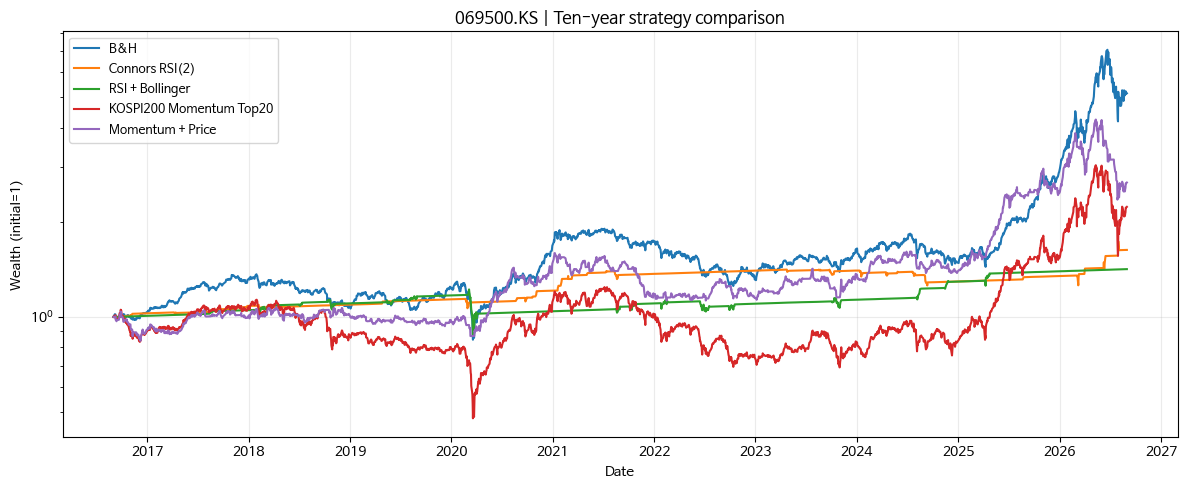

In [ ]:
FULL, FULL_STATS = run_comparison(
    PRICES, SIGNALS, RF, BACKTEST_START, BACKTEST_END, COST_BPS)
STRATEGY_ORDER = ['B&H', 'Connors RSI(2)', 'RSI + Bollinger', MOM_NAME, PRICE_NAME]
FULL_STATS = FULL_STATS.reindex(STRATEGY_ORDER)
SUMMARY = FULL_STATS[['CAGR','MDD','Sharpe','Exposure','TotalReturn']].rename(columns={
    'Exposure':'AvgInvestedFraction'})
show_table(SUMMARY, {
    'CAGR':'{:+.2%}', 'MDD':'{:.2%}', 'Sharpe':'{:.2f}',
    'AvgInvestedFraction':'{:.1%}', 'TotalReturn':'{:+.2%}'})
fig, ax = plt.subplots(figsize=(12,5))
for name in STRATEGY_ORDER:
    bt = FULL[name]
    ax.plot(bt.index, bt.equity, label=name)
ax.set(title=f'{TICKER} | Ten-year strategy comparison',
       ylabel='Wealth (initial=1)', yscale='log', xlabel='Date')
ax.legend(fontsize=9); ax.grid(alpha=.25)
plt.tight_layout()
fig.savefig(OUT/'strategy_comparison_10y.png', dpi=180, bbox_inches='tight')
plt.show()

## 4. Momentum + Price 매매 시점
두 시장 모두 2020년을 확대해 가격 신호와 청산·재진입 시점을 확인한다. `DETAIL_START`, `DETAIL_END`로 표시 구간을 변경할 수 있다. 이 그래프는 규칙 설명용이며 성과 비교는 전체 10년을 사용한다.
KODEX 200 가격은 매매 판단의 기준이다. 실제 거래 대상은 선정된 Top20 종목이다. 회색 영역은 현금 전환 지시가 적용된 기간, 삼각형은 청산·재진입 실행일이다. 표시는 ETF 시가 위치이며 개별 종목의 체결가격은 아니다.

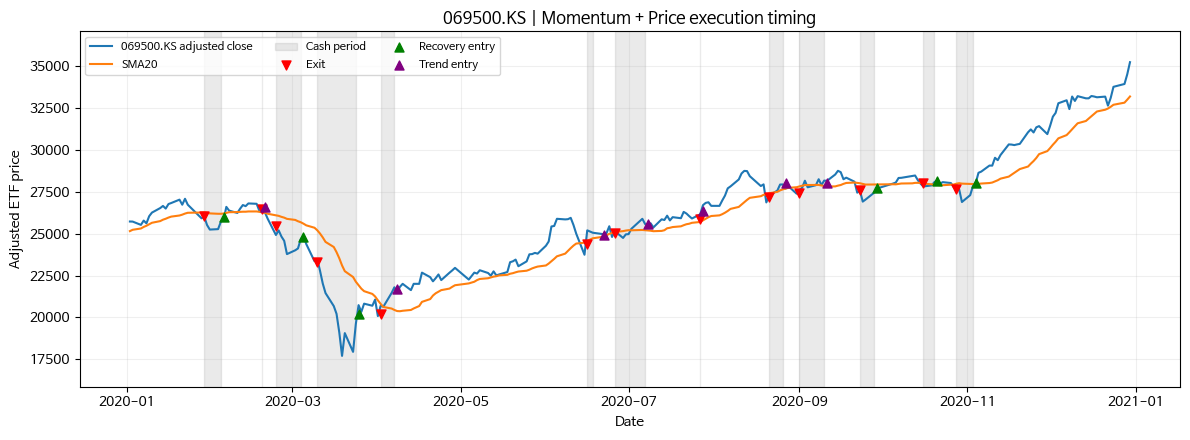

In [ ]:
view_dates = FULL[PRICE_NAME].index
view_dates = view_dates[(view_dates >= pd.Timestamp(DETAIL_START)) &
                        (view_dates < pd.Timestamp(DETAIL_END))]
if len(view_dates) == 0:
    raise ValueError('DETAIL_START/DETAIL_END must overlap the backtest period.')
fig, ax = plt.subplots(figsize=(12,4.5))
ax.plot(view_dates, PX.reindex(view_dates), label=f'{TICKER} adjusted close', color='tab:blue')
ax.plot(view_dates, PRICE_FEATURES.sma20.reindex(view_dates), label='SMA20', color='tab:orange')
executed_gate = PRICE_STATE.gate.shift(1).reindex(view_dates)
ax.fill_between(view_dates, 0, 1, where=executed_gate.eq(0),
    transform=ax.get_xaxis_transform(), color='gray', alpha=.16, label='Cash period')
execution_events = PRICE_STATE.event.shift(1).reindex(view_dates)
for event, marker, color, label in [
    ('exit_breakdown','v','red','Exit'),
    ('enter_recovery','^','green','Recovery entry'),
    ('enter_trend','^','purple','Trend entry')]:
    mask = execution_events.eq(event)
    ax.scatter(view_dates[mask], PRICES.Open.reindex(view_dates)[mask],
               marker=marker, color=color, label=label, s=42, zorder=4)
ax.set(title=f'{TICKER} | Momentum + Price execution timing',
       ylabel='Adjusted ETF price', xlabel='Date')
ax.legend(fontsize=8, ncol=3); ax.grid(alpha=.2)
plt.tight_layout()
fig.savefig(OUT/'price_execution_detail.png', dpi=180, bbox_inches='tight')
plt.show()

## 5. 거래비용에 따른 성과 변화
편도 거래비용을 0·5·15bp로 설정하고 기본 모멘텀과 Momentum + Price의 CAGR·Sharpe를 비교한다. 평가 기간과 현금 수익률은 동일하게 유지한다. 1bp는 0.01%이다.

In [ ]:
cost_rows = []
for cost in COST_SCENARIOS_BPS:
    if cost == COST_BPS:
        base_bt, price_bt = FULL[MOM_NAME], FULL[PRICE_NAME]
    else:
        base_bt = q.stock_momentum_backtest(
            PANEL, TARGETS, RF, BACKTEST_START, BACKTEST_END, cost,
            missing_policy=MISSING_EXECUTION_POLICY)
        price_bt = q.price_momentum_backtest(
            PANEL, TARGETS, RF, BACKTEST_START, BACKTEST_END, cost,
            daily_gate=PRICE_STATE.gate, missing_policy=MISSING_EXECUTION_POLICY)
    for name, bt in [(MOM_NAME, base_bt), (PRICE_NAME, price_bt)]:
        stats = q.perf_stats(bt)
        cost_rows.append({'CostBps':cost, 'Strategy':name,
                          'CAGR':stats['CAGR'], 'Sharpe':stats['Sharpe']})
COST_TABLE = pd.DataFrame(cost_rows).set_index(['CostBps','Strategy'])
show_table(COST_TABLE, {'CAGR':'{:+.2%}','Sharpe':'{:.2f}'})

/tmp/ipykernel_1643/2308796317.py:6: UserWarning: APPROXIMATE backtest: 22 data events; inspect attrs['data_events']. These are not actual corporate-action settlements.
  base_bt = q.stock_momentum_backtest(
/tmp/ipykernel_1643/2308796317.py:9: UserWarning: APPROXIMATE backtest: 66 data events; inspect attrs['data_events']. These are not actual corporate-action settlements.
  price_bt = q.price_momentum_backtest(
/tmp/ipykernel_1643/2308796317.py:6: UserWarning: APPROXIMATE backtest: 22 data events; inspect attrs['data_events']. These are not actual corporate-action settlements.
  base_bt = q.stock_momentum_backtest(
/tmp/ipykernel_1643/2308796317.py:9: UserWarning: APPROXIMATE backtest: 66 data events; inspect attrs['data_events']. These are not actual corporate-action settlements.
  price_bt = q.price_momentum_backtest(


## 6. 결과 저장
전체 기간 성과표, 거래비용 비교표, 일별 자산·보유수량, 가격 신호 기록, 그래프와 설정을 저장한다. 가격 누락·거래 불가 처리 내역은 `data_events` 파일에서 확인할 수 있다.

In [ ]:
FULL_STATS.to_csv(OUT/'performance_full.csv')
SUMMARY.to_csv(OUT/'performance_summary.csv')
COST_TABLE.to_csv(OUT/'cost_sensitivity.csv')
PRICE_FEATURES.to_csv(OUT/'price_features.csv')
PRICE_STATE.to_csv(OUT/'price_state_audit.csv')
for name, bt in FULL.items():
    safe = name.replace(' + ','_').replace(' ','_').replace('&','and')
    bt.to_csv(OUT/f'full_{safe}_daily.csv')
    for attr in ['holdings','data_events','trades']:
        if attr in bt.attrs:
            bt.attrs[attr].to_csv(OUT/f'full_{safe}_{attr}.csv',index=False)
versions={}
for package in ['numpy', 'pandas', 'matplotlib', 'yfinance', 'pykrx']:
    try: versions[package]=importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError: versions[package]='not installed'
meta=dict(market='KOSPI 200',ticker=TICKER,strategies=STRATEGY_ORDER,
    backtest_start=BACKTEST_START,backtest_end_exclusive=BACKTEST_END,
    fetch_start=FETCH_START,cost_bps=COST_BPS,cost_scenarios=COST_SCENARIOS_BPS,
    rf_annual_assumption=RF_ANNUAL,detail_window=[DETAIL_START,DETAIL_END],
    execution='close decision -> next session open; adjusted units',
    final_liquidation=False,missing_execution_policy=MISSING_EXECUTION_POLICY,
    tax_model='not modeled',data=dict(PRICES.attrs),versions=versions,
    code_sha256=hashlib.sha256(Path(q.__file__).read_bytes()).hexdigest(),
    stock_panel_sha256=hashlib.sha256(STOCK_PANEL_CSV.read_bytes()).hexdigest(),
    momentum=dict(top_n=20,rebalance='quarterly',positive_filter=False,cap_filter=False),
    price_overlay=q.PRICE_PARAMS,
    connors=dict(rsi_period=2,entry_rsi_lt=5,entry_sma=200,exit_sma=5),
    rsi_bollinger=dict(rsi_period=14,entry_rsi_lt=30,exit_rsi_gt=50,bb_n=20,bb_k=2))
source_meta = STOCK_PANEL_CSV.with_suffix('.csv.meta.json')
if source_meta.exists():meta['panel_source']=json.loads(source_meta.read_text())
(OUT/'settings.json').write_text(json.dumps(meta,ensure_ascii=False,indent=2),encoding='utf-8')
print('Saved:', OUT)

Saved: /content/results/KOSPI200_final
